### **This new notebook is for the 4 Features, 1 qubit per feature experiment, in total we have 4 Qubits. This notebook reutilizes a lot of code in QAOA_4F2Q_8Q.ipynb if you want to get a deeper insight you can refer to that notebook is well documented code**

**Imports**

In [1]:
import math
from typing import Any

import kirin
from kirin.dialects import ilist
from bloqade import qasm2

**Variables for 4F1Q 4 Qubit in total experiment**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import product

# ========= Problem definition (4 assets / 4 qubits) =========
n_qubits = 4

asset_labels = [
    "A017 (Gov Bonds)",
    "A026 (IG Credit)",
    "A007 (Cash)",
    "A047 (HY Credit)",
]

# Ground truth from brute force
ground_truth_x = np.array([0, 0, 1, 1], dtype=int)
ground_truth_energy = -0.007414

# Ising local fields h
h_terms = np.array([
    0.028200,
    0.016020,
    0.035460,
    0.006839
], dtype=float)

# Ising couplings J as symmetric matrix
J_terms = np.zeros((4,4), dtype=float)
J_terms[0,1] = 0.120003
J_terms[0,2] = 0.250002
J_terms[0,3] = 0.060001
J_terms[1,2] = 0.150001
J_terms[1,3] = 0.036002
J_terms[2,3] = 0.075002

J_terms[1,0] = J_terms[0,1]
J_terms[2,0] = J_terms[0,2]
J_terms[3,0] = J_terms[0,3]
J_terms[2,1] = J_terms[1,2]
J_terms[3,1] = J_terms[1,3]
J_terms[3,2] = J_terms[2,3]

# Constant shift (does not affect argmin, but useful for reporting)
ising_offset = 0.295508
ground_truth_bits = "0011"

print("n_qubits =", n_qubits)
print("ground_truth_bits =", ground_truth_bits)
print("ground_truth_energy =", ground_truth_energy)
print("h_terms =", h_terms)
print("J_terms =\n", J_terms)

n_qubits = 4
ground_truth_bits = 0011
ground_truth_energy = -0.007414
h_terms = [0.0282   0.01602  0.03546  0.006839]
J_terms =
 [[0.       0.120003 0.250002 0.060001]
 [0.120003 0.       0.150001 0.036002]
 [0.250002 0.150001 0.       0.075002]
 [0.060001 0.036002 0.075002 0.      ]]


### **Construct the circuit**

In [3]:
def build_qaoa_ising_kernel(n_qubits, h_terms, J_terms):
    @qasm2.extended
    def kernel(gamma: ilist.IList[float, Any], beta: ilist.IList[float, Any]):
        q = qasm2.qreg(n_qubits)

        for i in range(n_qubits):
            qasm2.h(q[i])

        for layer in range(len(gamma)):
            g = gamma[layer]
            b = beta[layer]

            for k in range(len(h_terms)):
                term = h_terms[k]
                i = term[0]
                hi = term[1]
                qasm2.rz(q[i], 2.0 * g * hi)

            for k in range(len(J_terms)):
                term = J_terms[k]
                i = term[0]
                j = term[1]
                Jij = term[2]

                qasm2.cx(q[i], q[j])
                qasm2.rz(q[j], 2.0 * g * Jij)
                qasm2.cx(q[i], q[j])

            for i in range(n_qubits):
                qasm2.rx(q[i], 2.0 * b)

        return q

    return kernel

# P [1,2,3] , Optimizer = COBYLA

### **Inference cell**

**New inference cell to run different P values**

In [4]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from bloqade.pyqrack import StackMemorySimulator

# =========================================================
# CLEAN MULTI-P RUNNER
# Freezes the Ising Hamiltonian once so notebook variable
# collisions do not break P=2, P=3, etc.
# =========================================================

# -------- freeze Hamiltonian ONCE with new names --------
h_base = np.array(h_terms, dtype=float).reshape(-1).copy()
J_base = np.array(J_terms, dtype=float).copy()

assert h_base.shape == (n_qubits,), f"h_base shape inesperada: {h_base.shape}"
assert J_base.shape == (n_qubits, n_qubits), f"J_base shape inesperada: {J_base.shape}"

print("Frozen h_base shape:", h_base.shape)
print("Frozen J_base shape:", J_base.shape)

# -------- Bloqade-format terms built ONCE --------
h_kernel_terms = [(i, float(h_base[i])) for i in range(n_qubits)]

J_kernel_terms = []
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        if abs(J_base[i, j]) > 1e-12:
            J_kernel_terms.append((i, j, float(J_base[i, j])))

print("h_kernel_terms =", h_kernel_terms)
print("J_kernel_terms =", J_kernel_terms)

# -------- build kernel + simulator ONCE --------
kernel = build_qaoa_ising_kernel(
    n_qubits=n_qubits,
    h_terms=h_kernel_terms,
    J_terms=J_kernel_terms
)

sim = StackMemorySimulator(min_qubits=n_qubits)

# -------- helper functions --------
def join_theta(gamma_vals, beta_vals):
    return np.array(list(gamma_vals) + list(beta_vals), dtype=float)

def split_theta(theta, p):
    theta = np.array(theta, dtype=float)
    gamma_vals = theta[:p].tolist()
    beta_vals = theta[p:2*p].tolist()
    return gamma_vals, beta_vals

def ising_energy_from_x_list_local(x_list, h_local, J_local, const=0.0):
    x = np.array(x_list, dtype=int)
    s = 2 * x - 1
    e = 0.0

    for i in range(len(s)):
        e += float(h_local[i]) * s[i]

    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            e += float(J_local[i, j]) * s[i] * s[j]

    return float(e + const)

def sample_counts_from_probs(probs, shots=1000, seed=123):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(probs))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    sampled = rng.choice(indices, size=shots, p=probs)

    counts = {}
    for idx in sampled:
        bitstring = format(idx, f"0{n_qubits}b")
        counts[bitstring] = counts.get(bitstring, 0) + 1

    return dict(sorted(counts.items(), key=lambda kv: kv[1], reverse=True))

# -------- experiment settings --------
P_values = [1, 2, 3]
MAXITER = 5000
RHOBEG = 0.2
METHOD = "COBYLA"
SHOTS = 2000
SEED = 123

experiment_results = []

for P in P_values:
    print(f"\n========== RUNNING P={P} ==========")
    t0 = time.time()

    INITIAL_POINTS = [
        ([0.3] * P, [0.2] * P),
        ([0.5] * P, [0.5] * P),
        ([1.0] * P, [0.5] * P),
        ([2.0] * P, [1.0] * P),
        ([np.pi / 2] * P, [np.pi / 4] * P),
    ]

    def probs_from_theta(theta):
        gamma_vals, beta_vals = split_theta(theta, P)
        ket = sim.state_vector(kernel, args=(gamma_vals, beta_vals))
        probs = np.abs(np.array(ket)) ** 2
        probs = probs / probs.sum()
        return probs

    def expected_ising_energy_for_theta(theta):
        probs = probs_from_theta(theta)
        exp_energy = 0.0
        for idx in range(2 ** n_qubits):
            bitstring = format(idx, f"0{n_qubits}b")
            x_list = [int(b) for b in bitstring]
            energy = ising_energy_from_x_list_local(x_list, h_base, J_base, ising_offset)
            exp_energy += probs[idx] * energy
        return float(exp_energy)

    def optimize_once(theta0):
        def objective(theta):
            return expected_ising_energy_for_theta(theta)

        result = minimize(
            objective,
            theta0,
            method=METHOD,
            options={"maxiter": MAXITER, "rhobeg": RHOBEG}
        )
        return result

    best_result = None
    best_theta0 = None

    for gamma0, beta0 in INITIAL_POINTS:
        theta0 = join_theta(gamma0, beta0)
        result = optimize_once(theta0)

        if best_result is None or result.fun < best_result.fun:
            best_result = result
            best_theta0 = theta0

    best_gamma, best_beta = split_theta(best_result.x, P)

    ket_opt = sim.state_vector(kernel, args=(best_gamma, best_beta))
    probs_opt = np.abs(np.array(ket_opt)) ** 2
    probs_opt = probs_opt / probs_opt.sum()

    gt_index = int(ground_truth_bits, 2)
    gt_prob = float(probs_opt[gt_index])

    top_index = int(np.argmax(probs_opt))
    top_bitstring = format(top_index, f"0{n_qubits}b")

    runtime_sec = time.time() - t0

    experiment_results.append({
        "P": P,
        "runtime_sec": runtime_sec,
        "best_theta0": best_theta0.copy(),
        "best_gamma": best_gamma,
        "best_beta": best_beta,
        "best_fun": float(best_result.fun),
        "expected_energy": float(best_result.fun),
        "ground_truth_probability": gt_prob,
        "top_bitstring": top_bitstring,
        "top_probability": float(probs_opt[top_index]),
        "probs_opt": probs_opt.copy(),
        "counts": sample_counts_from_probs(probs_opt, shots=SHOTS, seed=SEED),
    })

    print(f"P={P} done")
    print("  best_gamma =", best_gamma)
    print("  best_beta =", best_beta)
    print("  expected_energy =", float(best_result.fun))
    print("  ground_truth_probability =", gt_prob)
    print("  top_bitstring =", top_bitstring)
    print("  top_probability =", float(probs_opt[top_index]))
    print("  runtime_sec =", runtime_sec)

Frozen h_base shape: (4,)
Frozen J_base shape: (4, 4)
h_kernel_terms = [(0, 0.0282), (1, 0.01602), (2, 0.03546), (3, 0.006839)]
J_kernel_terms = [(0, 1, 0.120003), (0, 2, 0.250002), (0, 3, 0.060001), (1, 2, 0.150001), (1, 3, 0.036002), (2, 3, 0.075002)]

========== RUNNING P=1 ==========
P=1 done
  best_gamma = [1.6756034256634205]
  best_beta = [1.2889677969974112]
  expected_energy = 0.19285626120874821
  ground_truth_probability = 0.11116393658979765
  top_bitstring = 1100
  top_probability = 0.117169814985829
  runtime_sec = 2.612144708633423

========== RUNNING P=2 ==========
P=2 done
  best_gamma = [3.656386896840261, 3.275636608869165]
  best_beta = [0.9110012198822036, 1.0556512126652766]
  expected_energy = 0.1073815003219035
  ground_truth_probability = 0.129245953776064
  top_bitstring = 1010
  top_probability = 0.17473800851119975
  runtime_sec = 36.39855217933655

========== RUNNING P=3 ==========
P=3 done
  best_gamma = [3.53128286749554, 2.06019866347077, 3.1040314796740

### This cell is intended to run after the COLYBA inference so we can actually store the values of the best run circuit and visualize it on qiskit

In [5]:
# =========================================================
# Select best COBYLA run overall
# Criterion: highest ground-truth probability
# =========================================================

best_idx_cobyla = max(
    range(len(experiment_results)),
    key=lambda i: experiment_results[i]["ground_truth_probability"]
)

best_run_cobyla = experiment_results[best_idx_cobyla]

print("Best COBYLA overall selected")
print("P =", best_run_cobyla["P"])
print("best_gamma =", best_run_cobyla["best_gamma"])
print("best_beta =", best_run_cobyla["best_beta"])
print("expected_energy =", best_run_cobyla["expected_energy"])
print("ground_truth_probability =", best_run_cobyla["ground_truth_probability"])
print("top_bitstring =", best_run_cobyla["top_bitstring"])
print("top_probability =", best_run_cobyla["top_probability"])

Best COBYLA overall selected
P = 3
best_gamma = [3.53128286749554, 2.06019866347077, 3.104031479674032]
best_beta = [2.1011116232469633, 0.6517579291780351, 0.7859330121945816]
expected_energy = 0.06359576448619311
ground_truth_probability = 0.17063194242226543
top_bitstring = 0011
top_probability = 0.17063194242226543


In [6]:
ground_state_bitstring = ground_truth_bits
ground_state_energy = -0.007414  # from brute force / validated Ising

print("===================================")
print("CLASSICAL TARGET")
print("===================================")
print("Ground-state bitstring :", ground_state_bitstring)
print("Ground-state energy    :", ground_state_energy)

print("\n===================================")
print("QAOA vs TARGET")
print("===================================")

for r in experiment_results:
    gap_to_target = r["expected_energy"] - ground_state_energy
    print(f"P={r['P']}")
    print(f"  expected_energy         = {r['expected_energy']:.9f}")
    print(f"  target_energy           = {ground_state_energy:.9f}")
    print(f"  energy_gap_to_target    = {gap_to_target:.9f}")
    print(f"  ground_truth_probability= {r['ground_truth_probability']:.9f}")
    print(f"  top_bitstring           = {r['top_bitstring']}")
    print(f"  top_probability         = {r['top_probability']:.9f}")
    print()

CLASSICAL TARGET
Ground-state bitstring : 0011
Ground-state energy    : -0.007414

QAOA vs TARGET
P=1
  expected_energy         = 0.192856261
  target_energy           = -0.007414000
  energy_gap_to_target    = 0.200270261
  ground_truth_probability= 0.111163937
  top_bitstring           = 1100
  top_probability         = 0.117169815

P=2
  expected_energy         = 0.107381500
  target_energy           = -0.007414000
  energy_gap_to_target    = 0.114795500
  ground_truth_probability= 0.129245954
  top_bitstring           = 1010
  top_probability         = 0.174738009

P=3
  expected_energy         = 0.063595764
  target_energy           = -0.007414000
  energy_gap_to_target    = 0.071009764
  ground_truth_probability= 0.170631942
  top_bitstring           = 0011
  top_probability         = 0.170631942



**Summary Table Function**

In [7]:
summary_df = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "best_fun": r["best_fun"],
        "expected_energy": r["expected_energy"],
        "ground_truth_probability": r["ground_truth_probability"],
        "top_bitstring": r["top_bitstring"],
        "top_probability": r["top_probability"],
    }
    for r in experiment_results
])

summary_df.sort_values("P").reset_index(drop=True)

,P,runtime_sec,best_fun,expected_energy,ground_truth_probability,top_bitstring,top_probability
0,1,2.612145,0.192856,0.192856,0.111164,1100,0.117170
1,2,36.398552,0.107382,0.107382,0.129246,1010,0.174738
2,3,97.991832,0.063596,0.063596,0.170632,0011,0.170632


**1ST Graph, Expected energy vs P**

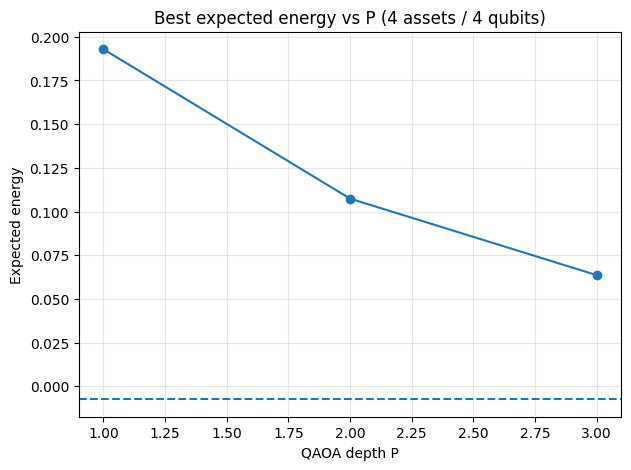

In [8]:
plot_df = summary_df.sort_values("P")

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["expected_energy"], marker="o")
plt.axhline(ground_truth_energy, linestyle="--")
plt.xlabel("QAOA depth P")
plt.ylabel("Expected energy")
plt.title("Best expected energy vs P (4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.show()

**2ST Graph, Runtime vs P**

   P  runtime_sec  expected_energy  energy_loss  ground_truth_probability
0  1     2.612145         0.192856     0.200270                  0.111164
1  2    36.398552         0.107382     0.114795                  0.129246
2  3    97.991832         0.063596     0.071010                  0.170632


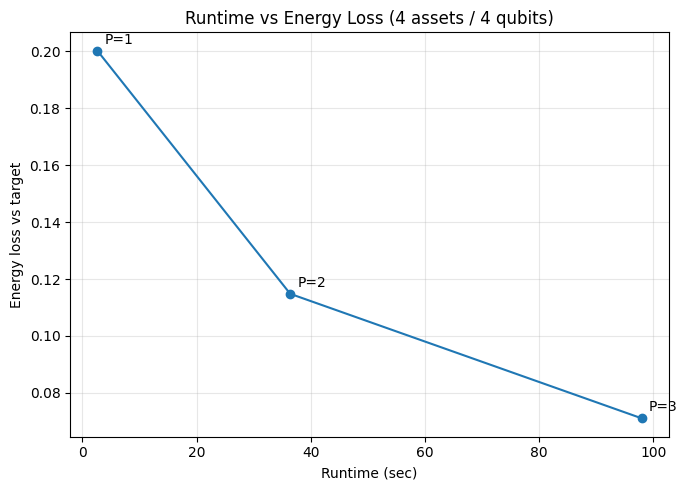

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

target_energy = -0.007413805245517935

plot_df = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "expected_energy": r["expected_energy"],
        "energy_loss": r["expected_energy"] - target_energy,
        "ground_truth_probability": r["ground_truth_probability"],
    }
    for r in experiment_results
]).sort_values("P").reset_index(drop=True)

print(plot_df)

plt.figure(figsize=(7,5))
plt.plot(plot_df["runtime_sec"], plot_df["energy_loss"], marker="o")
for _, row in plot_df.iterrows():
    plt.annotate(f'P={int(row["P"])}', (row["runtime_sec"], row["energy_loss"]), xytext=(5,5), textcoords="offset points")
plt.xlabel("Runtime (sec)")
plt.ylabel("Energy loss vs target")
plt.title("Runtime vs Energy Loss (4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Qubit plot**

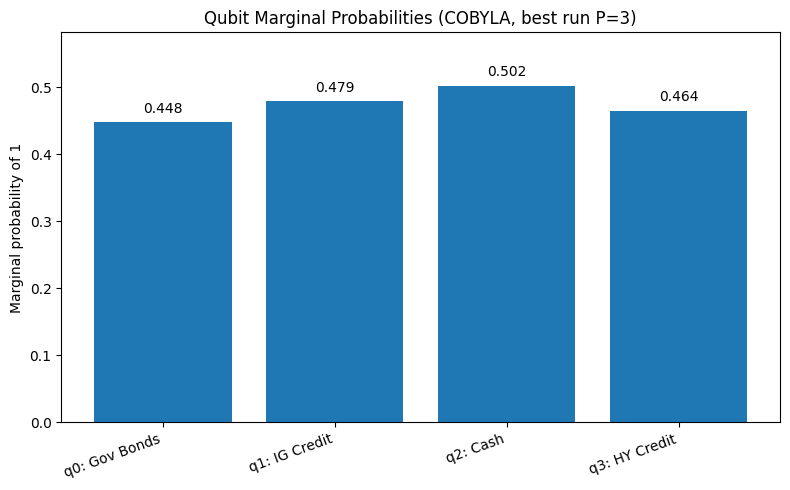

Best COBYLA run P = 3
Best gamma = [3.53128286749554, 2.06019866347077, 3.104031479674032]
Best beta = [2.1011116232469633, 0.6517579291780351, 0.7859330121945816]
Expected energy = 0.06359576448619311
Ground-truth probability = 0.17063194242226543
Top bitstring = 0011
Top probability = 0.17063194242226543


In [10]:
import numpy as np
import matplotlib.pyplot as plt

best_idx = max(
    range(len(experiment_results)),
    key=lambda i: experiment_results[i]["ground_truth_probability"]
)
best_run = experiment_results[best_idx]

probs_opt = best_run["probs_opt"]
n_qubits_local = n_qubits

marginals = np.zeros(n_qubits_local, dtype=float)

for idx, p in enumerate(probs_opt):
    bitstring = format(idx, f"0{n_qubits_local}b")
    for q in range(n_qubits_local):
        if bitstring[q] == "1":
            marginals[q] += p

qubit_labels = [
    "q0: Gov Bonds",
    "q1: IG Credit",
    "q2: Cash",
    "q3: HY Credit",
]

plt.figure(figsize=(8,5))
bars = plt.bar(range(n_qubits_local), marginals)

plt.xticks(range(n_qubits_local), qubit_labels, rotation=20, ha="right")
plt.ylabel("Marginal probability of 1")
plt.title(f'Qubit Marginal Probabilities (COBYLA, best run P={best_run["P"]})')
plt.ylim(0, max(marginals) + 0.08)

for bar, val in zip(bars, marginals):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print("Best COBYLA run P =", best_run["P"])
print("Best gamma =", best_run["best_gamma"])
print("Best beta =", best_run["best_beta"])
print("Expected energy =", best_run["expected_energy"])
print("Ground-truth probability =", best_run["ground_truth_probability"])
print("Top bitstring =", best_run["top_bitstring"])
print("Top probability =", best_run["top_probability"])

# P [1,2,3] , Optimizer = Powell

In [11]:
import numpy as np

# ===== 4 assets / 4 qubits corrected Ising Hamiltonian =====
n_qubits = 4

h_terms = np.array([
    0.028200,
    0.016020,
    0.035460,
    0.006839
], dtype=float)

J_terms = np.zeros((4, 4), dtype=float)
J_terms[0,1] = 0.120003
J_terms[0,2] = 0.250002
J_terms[0,3] = 0.060001
J_terms[1,2] = 0.150001
J_terms[1,3] = 0.036002
J_terms[2,3] = 0.075002

J_terms[1,0] = J_terms[0,1]
J_terms[2,0] = J_terms[0,2]
J_terms[3,0] = J_terms[0,3]
J_terms[2,1] = J_terms[1,2]
J_terms[3,1] = J_terms[1,3]
J_terms[3,2] = J_terms[2,3]

ising_offset = 0.295508
ground_truth_bits = "0011"

print("4Q Hamiltonian loaded.")
print("n_qubits =", n_qubits)
print("h_terms shape =", h_terms.shape)
print("J_terms shape =", J_terms.shape)
print("ground_truth_bits =", ground_truth_bits)
print("ising_offset =", ising_offset)

4Q Hamiltonian loaded.
n_qubits = 4
h_terms shape = (4,)
J_terms shape = (4, 4)
ground_truth_bits = 0011
ising_offset = 0.295508


In [12]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from bloqade.pyqrack import StackMemorySimulator

# =========================================================
# MULTI-P RUNNER WITH POWELL
# Assumes already defined:
# - n_qubits
# - h_terms
# - J_terms
# - ising_offset
# - ground_truth_bits
# - build_qaoa_ising_kernel(...)
# =========================================================

# -------- freeze Hamiltonian once --------
h_base = np.array(h_terms, dtype=float).reshape(-1).copy()
J_base = np.array(J_terms, dtype=float).copy()

assert h_base.shape == (n_qubits,), f"h_base shape inesperada: {h_base.shape}"
assert J_base.shape == (n_qubits, n_qubits), f"J_base shape inesperada: {J_base.shape}"

print("Frozen h_base shape:", h_base.shape)
print("Frozen J_base shape:", J_base.shape)

# -------- Bloqade-format terms --------
h_kernel_terms = [(i, float(h_base[i])) for i in range(n_qubits)]

J_kernel_terms = []
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        if abs(J_base[i, j]) > 1e-12:
            J_kernel_terms.append((i, j, float(J_base[i, j])))

print("h_kernel_terms =", h_kernel_terms)
print("J_kernel_terms =", J_kernel_terms)

# -------- build kernel + simulator --------
kernel = build_qaoa_ising_kernel(
    n_qubits=n_qubits,
    h_terms=h_kernel_terms,
    J_terms=J_kernel_terms
)

sim = StackMemorySimulator(min_qubits=n_qubits)

# -------- helper functions --------
def join_theta(gamma_vals, beta_vals):
    return np.array(list(gamma_vals) + list(beta_vals), dtype=float)

def split_theta(theta, p):
    theta = np.array(theta, dtype=float)
    gamma_vals = theta[:p].tolist()
    beta_vals = theta[p:2*p].tolist()
    return gamma_vals, beta_vals

def ising_energy_from_x_list_local(x_list, h_local, J_local, const=0.0):
    x = np.array(x_list, dtype=int)
    s = 2 * x - 1
    e = 0.0

    for i in range(len(s)):
        e += float(h_local[i]) * s[i]

    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            e += float(J_local[i, j]) * s[i] * s[j]

    return float(e + const)

def sample_counts_from_probs(probs, shots=1000, seed=123):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(probs))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    sampled = rng.choice(indices, size=shots, p=probs)

    counts = {}
    for idx in sampled:
        bitstring = format(idx, f"0{n_qubits}b")
        counts[bitstring] = counts.get(bitstring, 0) + 1

    return dict(sorted(counts.items(), key=lambda kv: kv[1], reverse=True))

# -------- experiment settings --------
P_values = [1, 2, 3]

METHOD = "Powell"
MAXITER = 5000
XTOL = 1e-4
FTOL = 1e-4
SHOTS = 2000
SEED = 123

experiment_results_powell = []

for P in P_values:
    print(f"\n========== RUNNING POWELL, P={P} ==========")
    t0 = time.time()

    INITIAL_POINTS = [
        ([0.3] * P, [0.2] * P),
        ([0.5] * P, [0.5] * P),
        ([1.0] * P, [0.5] * P),
        ([2.0] * P, [1.0] * P),
        ([np.pi / 2] * P, [np.pi / 4] * P),
    ]

    def probs_from_theta(theta):
        gamma_vals, beta_vals = split_theta(theta, P)
        ket = sim.state_vector(kernel, args=(gamma_vals, beta_vals))
        probs = np.abs(np.array(ket)) ** 2
        probs = probs / probs.sum()
        return probs

    def expected_ising_energy_for_theta(theta):
        probs = probs_from_theta(theta)
        exp_energy = 0.0
        for idx in range(2 ** n_qubits):
            bitstring = format(idx, f"0{n_qubits}b")
            x_list = [int(b) for b in bitstring]
            energy = ising_energy_from_x_list_local(x_list, h_base, J_base, ising_offset)
            exp_energy += probs[idx] * energy
        return float(exp_energy)

    def optimize_once(theta0):
        def objective(theta):
            return expected_ising_energy_for_theta(theta)

        result = minimize(
            objective,
            theta0,
            method=METHOD,
            options={"maxiter": MAXITER, "xtol": XTOL, "ftol": FTOL}
        )
        return result

    best_result = None
    best_theta0 = None

    for gamma0, beta0 in INITIAL_POINTS:
        theta0 = join_theta(gamma0, beta0)
        result = optimize_once(theta0)

        if best_result is None or result.fun < best_result.fun:
            best_result = result
            best_theta0 = theta0

    best_gamma, best_beta = split_theta(best_result.x, P)

    ket_opt = sim.state_vector(kernel, args=(best_gamma, best_beta))
    probs_opt = np.abs(np.array(ket_opt)) ** 2
    probs_opt = probs_opt / probs_opt.sum()

    gt_index = int(ground_truth_bits, 2)
    gt_prob = float(probs_opt[gt_index])

    top_index = int(np.argmax(probs_opt))
    top_bitstring = format(top_index, f"0{n_qubits}b")

    runtime_sec = time.time() - t0

    experiment_results_powell.append({
        "P": P,
        "runtime_sec": runtime_sec,
        "best_theta0": best_theta0.copy(),
        "best_gamma": best_gamma,
        "best_beta": best_beta,
        "best_fun": float(best_result.fun),
        "expected_energy": float(best_result.fun),
        "ground_truth_probability": gt_prob,
        "top_bitstring": top_bitstring,
        "top_probability": float(probs_opt[top_index]),
        "probs_opt": probs_opt.copy(),
        "counts": sample_counts_from_probs(probs_opt, shots=SHOTS, seed=SEED),
        "optimizer": "Powell",
    })

    print(f"P={P} done")
    print("  best_gamma =", best_gamma)
    print("  best_beta =", best_beta)
    print("  expected_energy =", float(best_result.fun))
    print("  ground_truth_probability =", gt_prob)
    print("  top_bitstring =", top_bitstring)
    print("  top_probability =", float(probs_opt[top_index]))
    print("  runtime_sec =", runtime_sec)

Frozen h_base shape: (4,)
Frozen J_base shape: (4, 4)
h_kernel_terms = [(0, 0.0282), (1, 0.01602), (2, 0.03546), (3, 0.006839)]
J_kernel_terms = [(0, 1, 0.120003), (0, 2, 0.250002), (0, 3, 0.060001), (1, 2, 0.150001), (1, 3, 0.036002), (2, 3, 0.075002)]

========== RUNNING POWELL, P=1 ==========
P=1 done
  best_gamma = [1.677567779965253]
  best_beta = [1.2890666881686068]
  expected_energy = 0.1928561010630778
  ground_truth_probability = 0.11118893153334065
  top_bitstring = 1100
  top_probability = 0.11720693413372484
  runtime_sec = 1.607438325881958

========== RUNNING POWELL, P=2 ==========
P=2 done
  best_gamma = [3.6732906428854637, 3.2812789491297885]
  best_beta = [0.9120708954773362, 1.0558981956469566]
  expected_energy = 0.10737625504362268
  ground_truth_probability = 0.1293112452411384
  top_bitstring = 1010
  top_probability = 0.17440827482341428
  runtime_sec = 10.511151552200317

========== RUNNING POWELL, P=3 ==========
P=3 done
  best_gamma = [3.5546762591400864, 2.

### This cell is intended to run after the Powell inference so we can actually store the values and use them to visualize the best-run circuit

In [13]:
# =========================================================
# Select best Powell run overall
# Criterion: highest ground-truth probability
# =========================================================

best_idx_powell = max(
    range(len(experiment_results_powell)),
    key=lambda i: experiment_results_powell[i]["ground_truth_probability"]
)

best_run_powell = experiment_results_powell[best_idx_powell]

print("Best Powell overall selected")
print("P =", best_run_powell["P"])
print("best_gamma =", best_run_powell["best_gamma"])
print("best_beta =", best_run_powell["best_beta"])
print("expected_energy =", best_run_powell["expected_energy"])
print("ground_truth_probability =", best_run_powell["ground_truth_probability"])
print("top_bitstring =", best_run_powell["top_bitstring"])
print("top_probability =", best_run_powell["top_probability"])

Best Powell overall selected
P = 3
best_gamma = [3.5546762591400864, 2.0612898273749902, 3.100360372741673]
best_beta = [2.1044831835711912, 0.652838448788219, 0.7835789614094515]
expected_energy = 0.0635896171410879
ground_truth_probability = 0.17059258076608932
top_bitstring = 0011
top_probability = 0.17059258076608932


In [14]:
ground_state_bitstring = ground_truth_bits
ground_state_energy = -0.007413805245517935

print("===================================")
print("CLASSICAL TARGET")
print("===================================")
print("Ground-state bitstring :", ground_state_bitstring)
print("Ground-state energy    :", ground_state_energy)

print("\n===================================")
print("POWELL QAOA vs TARGET")
print("===================================")

for r in experiment_results_powell:
    gap_to_target = r["expected_energy"] - ground_state_energy
    print(f"P={r['P']}")
    print(f"  expected_energy          = {r['expected_energy']:.9f}")
    print(f"  target_energy            = {ground_state_energy:.9f}")
    print(f"  energy_gap_to_target     = {gap_to_target:.9f}")
    print(f"  ground_truth_probability = {r['ground_truth_probability']:.9f}")
    print(f"  top_bitstring            = {r['top_bitstring']}")
    print(f"  top_probability          = {r['top_probability']:.9f}")
    print()

CLASSICAL TARGET
Ground-state bitstring : 0011
Ground-state energy    : -0.007413805245517935

POWELL QAOA vs TARGET
P=1
  expected_energy          = 0.192856101
  target_energy            = -0.007413805
  energy_gap_to_target     = 0.200269906
  ground_truth_probability = 0.111188932
  top_bitstring            = 1100
  top_probability          = 0.117206934

P=2
  expected_energy          = 0.107376255
  target_energy            = -0.007413805
  energy_gap_to_target     = 0.114790060
  ground_truth_probability = 0.129311245
  top_bitstring            = 1010
  top_probability          = 0.174408275

P=3
  expected_energy          = 0.063589617
  target_energy            = -0.007413805
  energy_gap_to_target     = 0.071003422
  ground_truth_probability = 0.170592581
  top_bitstring            = 0011
  top_probability          = 0.170592581



In [15]:
summary_df_powell = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "best_fun": r["best_fun"],
        "expected_energy": r["expected_energy"],
        "ground_truth_probability": r["ground_truth_probability"],
        "top_bitstring": r["top_bitstring"],
        "top_probability": r["top_probability"],
        "optimizer": r["optimizer"],
    }
    for r in experiment_results_powell
])

summary_df_powell.sort_values("P").reset_index(drop=True)

,P,runtime_sec,best_fun,expected_energy,ground_truth_probability,top_bitstring,top_probability,optimizer
0,1,1.607438,0.192856,0.192856,0.111189,1100,0.117207,Powell
1,2,10.511152,0.107376,0.107376,0.129311,1010,0.174408,Powell
2,3,32.687426,0.063590,0.063590,0.170593,0011,0.170593,Powell


   P  expected_energy  energy_loss  runtime_sec  ground_truth_probability
0  1         0.192856     0.200270     2.612145                  0.111164
1  2         0.107382     0.114795    36.398552                  0.129246
2  3         0.063596     0.071010    97.991832                  0.170632


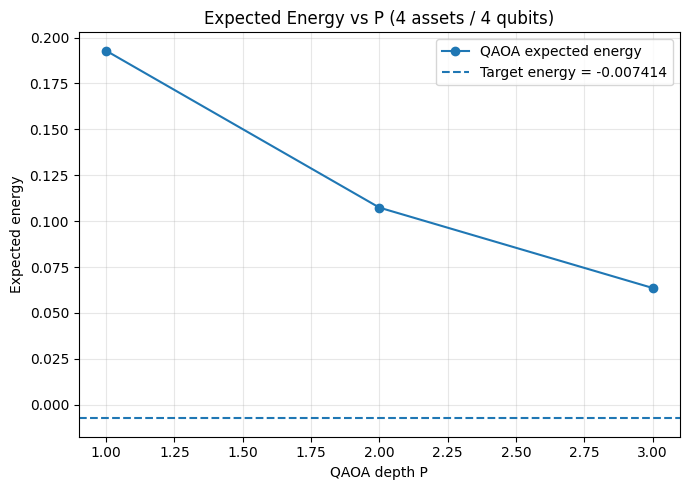

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

target_energy = -0.007413805245517935

plot_df = pd.DataFrame([
    {
        "P": r["P"],
        "expected_energy": r["expected_energy"],
        "energy_loss": r["expected_energy"] - target_energy,
        "runtime_sec": r["runtime_sec"],
        "ground_truth_probability": r["ground_truth_probability"],
    }
    for r in experiment_results
]).sort_values("P").reset_index(drop=True)

print(plot_df)

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["expected_energy"], marker="o", label="QAOA expected energy")
plt.axhline(target_energy, linestyle="--", label=f"Target energy = {target_energy:.6f}")
plt.xlabel("QAOA depth P")
plt.ylabel("Expected energy")
plt.title("Expected Energy vs P (4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

   P  runtime_sec  expected_energy  energy_loss  ground_truth_probability
0  1     1.607438         0.192856     0.200270                  0.111189
1  2    10.511152         0.107376     0.114790                  0.129311
2  3    32.687426         0.063590     0.071003                  0.170593


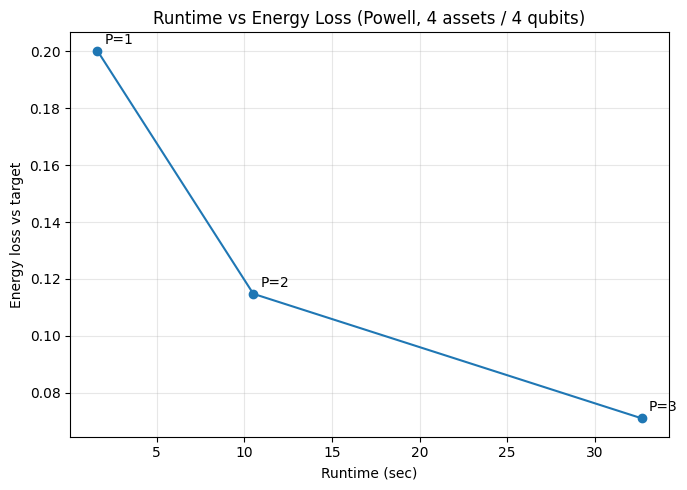

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

target_energy = -0.007413805245517935

plot_df_powell = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "expected_energy": r["expected_energy"],
        "energy_loss": r["expected_energy"] - target_energy,
        "ground_truth_probability": r["ground_truth_probability"],
    }
    for r in experiment_results_powell
]).sort_values("P").reset_index(drop=True)

print(plot_df_powell)

plt.figure(figsize=(7,5))
plt.plot(plot_df_powell["runtime_sec"], plot_df_powell["energy_loss"], marker="o")
for _, row in plot_df_powell.iterrows():
    plt.annotate(f'P={int(row["P"])}', (row["runtime_sec"], row["energy_loss"]), xytext=(5,5), textcoords="offset points")
plt.xlabel("Runtime (sec)")
plt.ylabel("Energy loss vs target")
plt.title("Runtime vs Energy Loss (Powell, 4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

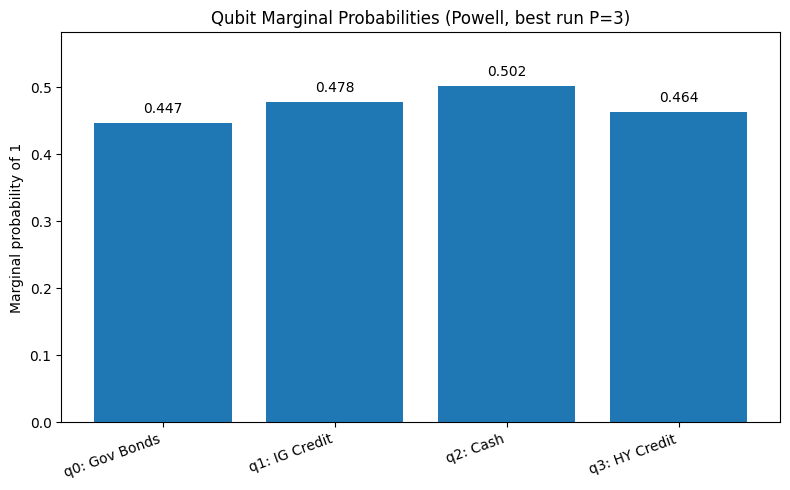

Best Powell run P = 3
Best gamma = [3.5546762591400864, 2.0612898273749902, 3.100360372741673]
Best beta = [2.1044831835711912, 0.652838448788219, 0.7835789614094515]
Expected energy = 0.0635896171410879
Ground-truth probability = 0.17059258076608932
Top bitstring = 0011
Top probability = 0.17059258076608932


In [18]:
import numpy as np
import matplotlib.pyplot as plt

best_idx_powell = max(
    range(len(experiment_results_powell)),
    key=lambda i: experiment_results_powell[i]["ground_truth_probability"]
)
best_run_powell = experiment_results_powell[best_idx_powell]

probs_opt = best_run_powell["probs_opt"]
n_qubits_local = n_qubits

marginals = np.zeros(n_qubits_local, dtype=float)

for idx, p in enumerate(probs_opt):
    bitstring = format(idx, f"0{n_qubits_local}b")
    for q in range(n_qubits_local):
        if bitstring[q] == "1":
            marginals[q] += p

qubit_labels = [
    "q0: Gov Bonds",
    "q1: IG Credit",
    "q2: Cash",
    "q3: HY Credit",
]

plt.figure(figsize=(8,5))
bars = plt.bar(range(n_qubits_local), marginals)

plt.xticks(range(n_qubits_local), qubit_labels, rotation=20, ha="right")
plt.ylabel("Marginal probability of 1")
plt.title(f'Qubit Marginal Probabilities (Powell, best run P={best_run_powell["P"]})')
plt.ylim(0, max(marginals) + 0.08)

for bar, val in zip(bars, marginals):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print("Best Powell run P =", best_run_powell["P"])
print("Best gamma =", best_run_powell["best_gamma"])
print("Best beta =", best_run_powell["best_beta"])
print("Expected energy =", best_run_powell["expected_energy"])
print("Ground-truth probability =", best_run_powell["ground_truth_probability"])
print("Top bitstring =", best_run_powell["top_bitstring"])
print("Top probability =", best_run_powell["top_probability"])

# **Visualize the circuits using Qiskit, only the best runs with the respective parameters already trained**

In [19]:
!pip install qiskit qiskit-aer pylatexenc -q

In [20]:
from qiskit import QuantumCircuit
from IPython.display import display

def build_qiskit_qaoa_ising_circuit(n_qubits, h_terms_struct, J_terms_struct, gamma_vals, beta_vals, add_measurements=False):
    qc = QuantumCircuit(n_qubits, n_qubits if add_measurements else 0)

    # Initial |+>^n
    for i in range(n_qubits):
        qc.h(i)

    # QAOA layers
    for layer in range(len(gamma_vals)):
        g = gamma_vals[layer]
        b = beta_vals[layer]

        # Cost unitary: local Z terms
        for k in range(len(h_terms_struct)):
            i = h_terms_struct[k][0]
            hi = h_terms_struct[k][1]
            qc.rz(2.0 * g * hi, i)

        # Cost unitary: ZZ couplings
        for k in range(len(J_terms_struct)):
            i = J_terms_struct[k][0]
            j = J_terms_struct[k][1]
            Jij = J_terms_struct[k][2]

            qc.cx(i, j)
            qc.rz(2.0 * g * Jij, j)
            qc.cx(i, j)

        # Mixer unitary
        for i in range(n_qubits):
            qc.rx(2.0 * b, i)

    if add_measurements:
        qc.measure(range(n_qubits), range(n_qubits))

    return qc

In [21]:
import numpy as np

n_qubits = 4

h_base = np.array([0.0282, 0.01602, 0.03546, 0.006839], dtype=float)

J_base = np.array([
    [0.0,      0.120003, 0.250002, 0.060001],
    [0.120003, 0.0,      0.150001, 0.036002],
    [0.250002, 0.150001, 0.0,      0.075002],
    [0.060001, 0.036002, 0.075002, 0.0     ],
], dtype=float)

h_kernel_terms = [(i, float(h_base[i])) for i in range(n_qubits)]
J_kernel_terms = [
    (i, j, float(J_base[i, j]))
    for i in range(n_qubits)
    for j in range(i + 1, n_qubits)
    if abs(J_base[i, j]) > 1e-15
]

print("h_kernel_terms =", h_kernel_terms)
print("J_kernel_terms =", J_kernel_terms)

h_kernel_terms = [(0, 0.0282), (1, 0.01602), (2, 0.03546), (3, 0.006839)]
J_kernel_terms = [(0, 1, 0.120003), (0, 2, 0.250002), (0, 3, 0.060001), (1, 2, 0.150001), (1, 3, 0.036002), (2, 3, 0.075002)]


### **COBYLA**

# **Best COLYBA run**

Best Powell P = 3


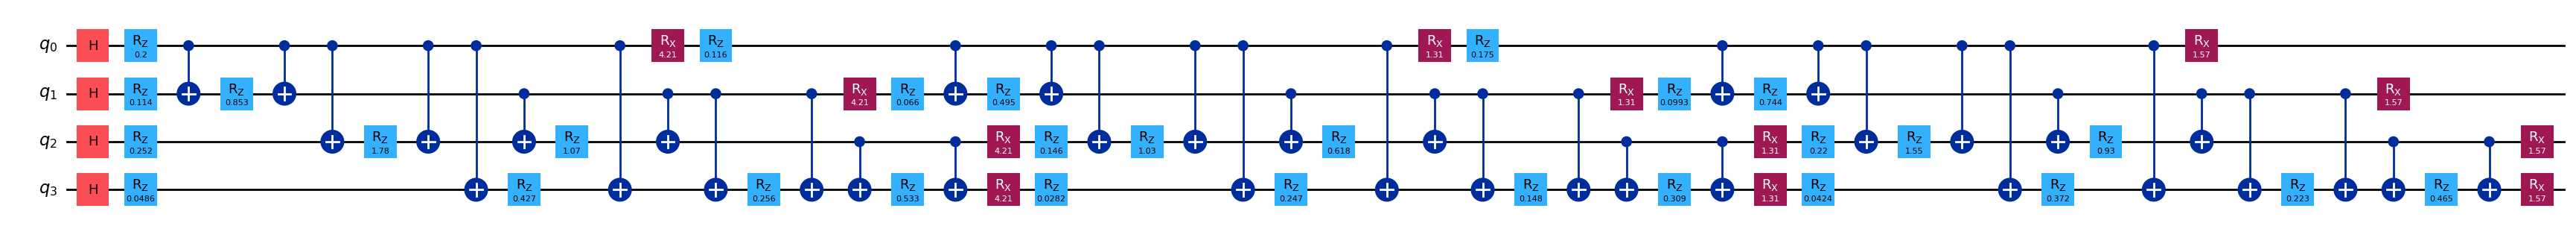

In [22]:
gamma_powell_best = best_run_powell["best_gamma"]
beta_powell_best  = best_run_powell["best_beta"]

qc_powell_best = build_qiskit_qaoa_ising_circuit(
    n_qubits=n_qubits,
    h_terms_struct=h_kernel_terms,
    J_terms_struct=J_kernel_terms,
    gamma_vals=gamma_powell_best,
    beta_vals=beta_powell_best,
    add_measurements=False
)

print("Best Powell P =", best_run_powell["P"])
display(qc_powell_best.draw("mpl", fold=-1))

# THESE ARE EXAMPLE RUNS, is the actual COBYLA but p1, p2, p3 so we can actually see the difference and put it in the presentations

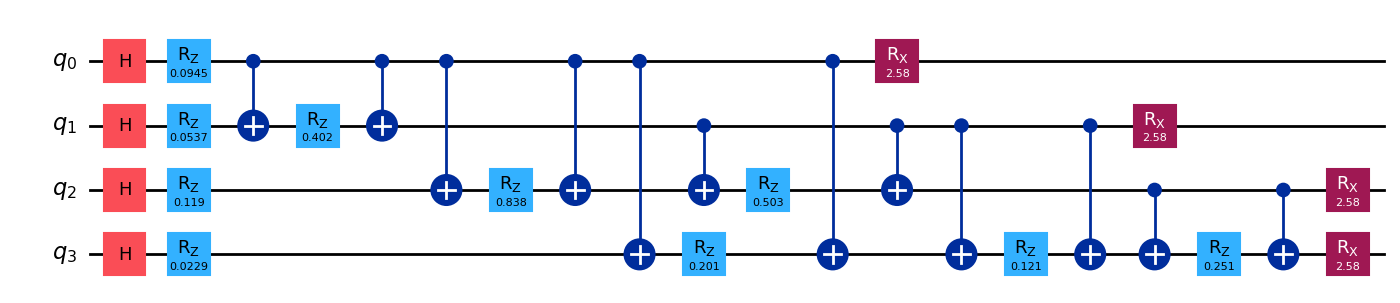

In [23]:
gamma_cobyla_p1 = [1.6754775339416066]
beta_cobyla_p1  = [1.288978527207045]

qc_cobyla_p1 = build_qiskit_qaoa_ising_circuit(
    n_qubits=n_qubits,
    h_terms_struct=h_kernel_terms,
    J_terms_struct=J_kernel_terms,
    gamma_vals=gamma_cobyla_p1,
    beta_vals=beta_cobyla_p1,
    add_measurements=False
)

display(qc_cobyla_p1.draw("mpl", fold=-1))

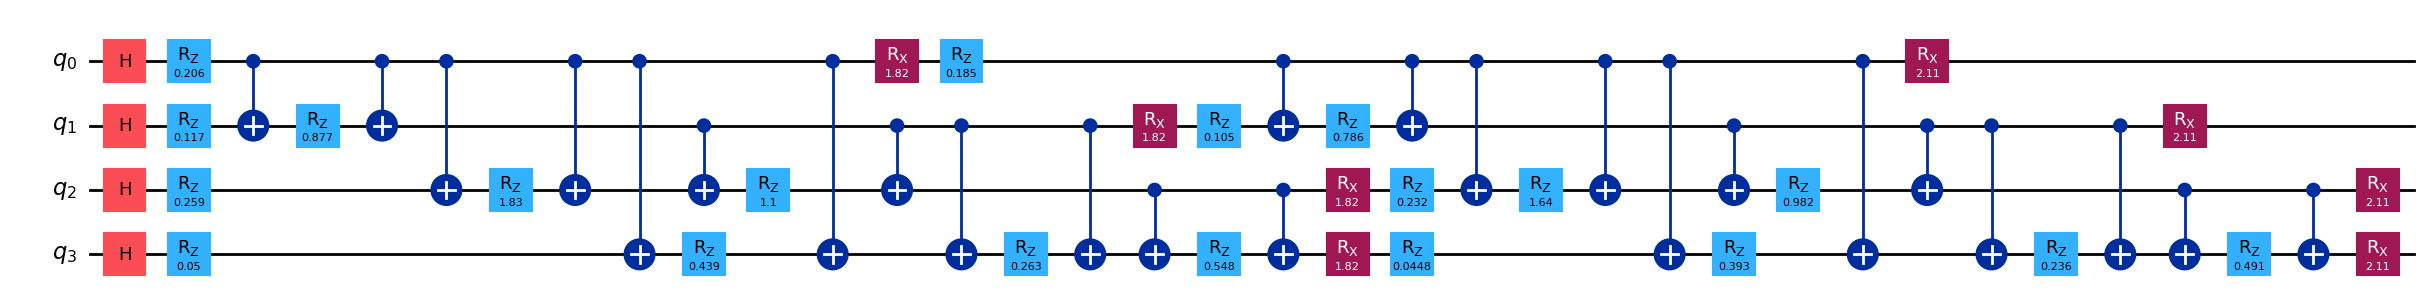

In [24]:
gamma_cobyla_p2 = [3.6543033903256203, 3.273714539097135]
beta_cobyla_p2  = [0.910852999859745, 1.055736545045174]

qc_cobyla_p2 = build_qiskit_qaoa_ising_circuit(
    n_qubits=n_qubits,
    h_terms_struct=h_kernel_terms,
    J_terms_struct=J_kernel_terms,
    gamma_vals=gamma_cobyla_p2,
    beta_vals=beta_cobyla_p2,
    add_measurements=False
)

display(qc_cobyla_p2.draw("mpl", fold=-1))

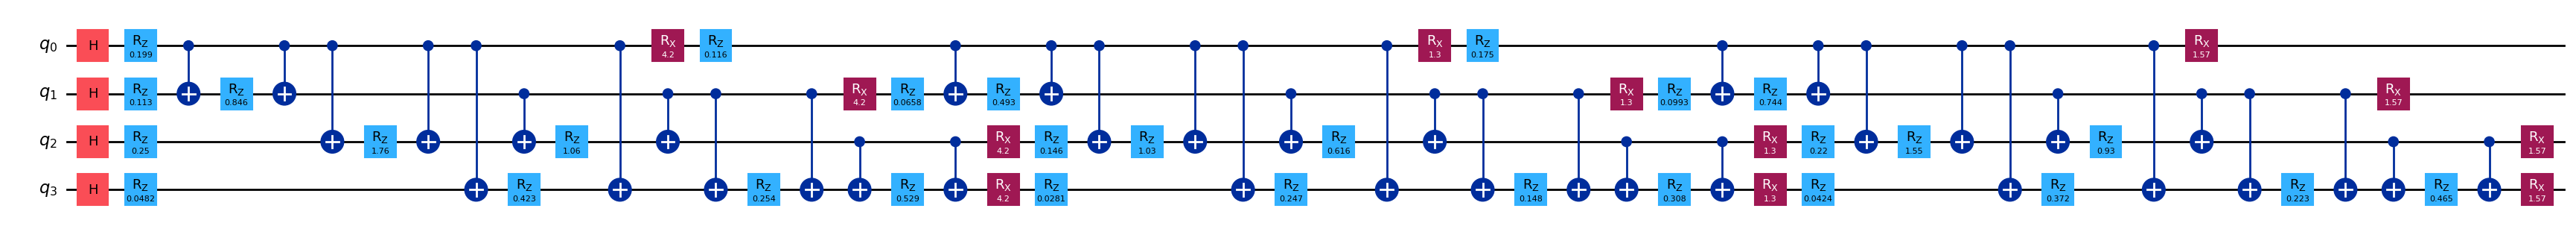

In [25]:
gamma_cobyla_p3 = [3.525412676855067, 2.0544742032872954, 3.0984011604710435]
beta_cobyla_p3  = [2.1006125514579654, 0.6506773823377708, 0.7867087680130788]

qc_cobyla_p3 = build_qiskit_qaoa_ising_circuit(
    n_qubits=n_qubits,
    h_terms_struct=h_kernel_terms,
    J_terms_struct=J_kernel_terms,
    gamma_vals=gamma_cobyla_p3,
    beta_vals=beta_cobyla_p3,
    add_measurements=False
)

display(qc_cobyla_p3.draw("mpl", fold=-1))

### **Powell**

# **Visualizar solo el mejor Powell**

Best Powell P = 3


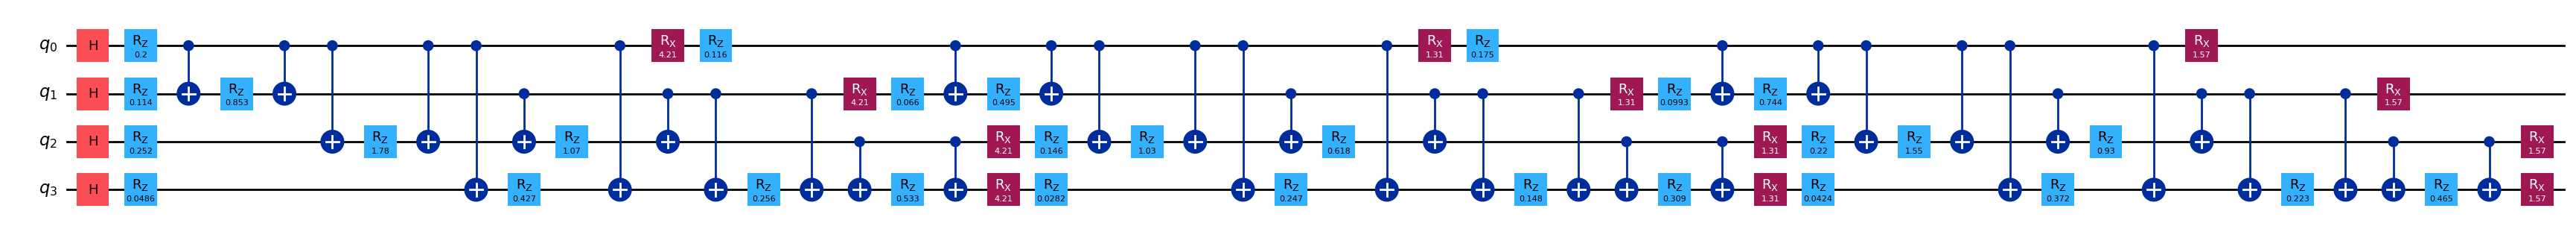

In [26]:
gamma_powell_best = best_run_powell["best_gamma"]
beta_powell_best  = best_run_powell["best_beta"]

qc_powell_best = build_qiskit_qaoa_ising_circuit(
    n_qubits=n_qubits,
    h_terms_struct=h_kernel_terms,
    J_terms_struct=J_kernel_terms,
    gamma_vals=gamma_powell_best,
    beta_vals=beta_powell_best,
    add_measurements=False
)

print("Best Powell P =", best_run_powell["P"])
display(qc_powell_best.draw("mpl", fold=-1))

# **Start adding NOISE to the best model/quantum circuit**

imports

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from bloqade import squin
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator

In [32]:
best_run_noise_ref = best_run_powell

In [33]:
gamma_opt = best_run_noise_ref["best_gamma"]
beta_opt  = best_run_noise_ref["best_beta"]

In [34]:
print("Using reference run for noise:")
print("P =", best_run_noise_ref["P"])
print("best_gamma =", best_run_noise_ref["best_gamma"])
print("best_beta  =", best_run_noise_ref["best_beta"])
print("expected_energy =", best_run_noise_ref["expected_energy"])
print("ground_truth_probability =", best_run_noise_ref["ground_truth_probability"])
print("top_bitstring =", best_run_noise_ref["top_bitstring"])

Using reference run for noise:
P = 3
best_gamma = [3.5546762591400864, 2.0612898273749902, 3.100360372741673]
best_beta  = [2.1044831835711912, 0.652838448788219, 0.7835789614094515]
expected_energy = 0.0635896171410879
ground_truth_probability = 0.17059258076608932
top_bitstring = 0011


Put gamma and beta parameters as a normal list

In [35]:
gamma_opt = list(best_run_noise_ref["best_gamma"])
beta_opt  = list(best_run_noise_ref["best_beta"])

print("gamma_opt =", gamma_opt)
print("beta_opt  =", beta_opt)
print("p_layers  =", len(gamma_opt))

gamma_opt = [3.5546762591400864, 2.0612898273749902, 3.100360372741673]
beta_opt  = [2.1044831835711912, 0.652838448788219, 0.7835789614094515]
p_layers  = 3


In [37]:
N_QUBITS = n_qubits
GROUND_TRUTH = ground_truth_bits
GROUND_ENERGY = ground_truth_energy

H_FIELDS = [float(x) for x in np.array(h_base, dtype=float).reshape(-1)]

J_COUPLINGS = []
for i in range(N_QUBITS):
    for j in range(i + 1, N_QUBITS):
        if abs(J_base[i, j]) > 1e-15:
            J_COUPLINGS.append((i, j, float(J_base[i, j])))

ISING_OFFSET = float(ising_offset)

print("N_QUBITS =", N_QUBITS)
print("GROUND_TRUTH =", GROUND_TRUTH)
print("GROUND_ENERGY =", GROUND_ENERGY)
print("ISING_OFFSET =", ISING_OFFSET)
print("H_FIELDS =", H_FIELDS)
print("J_COUPLINGS =", J_COUPLINGS)

N_QUBITS = 4
GROUND_TRUTH = 0011
GROUND_ENERGY = -0.007414
ISING_OFFSET = 0.295508
H_FIELDS = [0.0282, 0.01602, 0.03546, 0.006839]
J_COUPLINGS = [(0, 1, 0.120003), (0, 2, 0.250002), (0, 3, 0.060001), (1, 2, 0.150001), (1, 3, 0.036002), (2, 3, 0.075002)]


### **Build QAOA circuit again**

In [44]:
def make_qaoa_circuit(gamma_list, beta_list):
    p = len(gamma_list)

    @squin.kernel
    def qaoa():
        q = squin.qalloc(N_QUBITS)

        # Initial superposition
        for i in range(N_QUBITS):
            squin.h(q[i])

        # QAOA layers
        for layer in range(p):
            gamma = gamma_list[layer]
            beta = beta_list[layer]

            # ZZ cost terms
            for edge in J_COUPLINGS:
                i = edge[0]
                j = edge[1]
                jij = edge[2]

                squin.cx(q[i], q[j])
                squin.rz(2.0 * gamma * jij, q[j])
                squin.cx(q[i], q[j])

            # Local Z terms
            for i in range(N_QUBITS):
                squin.rz(2.0 * gamma * H_FIELDS[i], q[i])

            # Mixer
            for i in range(N_QUBITS):
                squin.rx(2.0 * beta, q[i])

        return q

    return qaoa

### **NOISE MODELS**

In [45]:
def get_noise_models():
    full_noise = noise.GeminiOneZoneNoiseModel()

    no_move_noise = noise.GeminiOneZoneNoiseModel(
        mover_px=0.0,
        sitter_px=0.0,
        mover_py=0.0,
        sitter_py=0.0,
        mover_pz=0.0,
        sitter_pz=0.0,
    )

    return {
        "clean": None,
        "one_zone_full": full_noise,
        "one_zone_no_moves": no_move_noise,
    }

In [46]:
def make_noisy_qaoa(gamma_list, beta_list, noise_model):
    clean_circuit = make_qaoa_circuit(gamma_list, beta_list)

    if noise_model is None:
        @squin.kernel
        def clean_with_measure():
            q = clean_circuit()
            bits = squin.broadcast.measure(q)
            return bits
        return clean_with_measure

    # squin -> cirq
    cirq_circuit = emit_circuit(clean_circuit, ignore_returns=True)

    # apply Bloqade noise model
    noisy_cirq = noise.transform_circuit(cirq_circuit, model=noise_model)

    # cirq -> squin
    noisy_kernel = load_circuit(
        noisy_cirq,
        kernel_name="noisy_qaoa",
        register_as_argument=True,
        return_register=True,
    )

    @squin.kernel
    def noisy_with_measure():
        q = squin.qalloc(N_QUBITS)
        q = noisy_kernel(q)
        bits = squin.broadcast.measure(q)
        return bits

    return noisy_with_measure

In [47]:
def run_circuit(kernel, shots=2000):
    simulator = StackMemorySimulator(min_qubits=N_QUBITS)
    task = simulator.task(kernel)

    counts = {}
    for _ in range(shots):
        result = task.run()
        bitstring = ''.join(str(int(b)) for b in result)
        counts[bitstring] = counts.get(bitstring, 0) + 1

    return counts


def evaluate_ising(bitstring):
    x = np.array([int(b) for b in bitstring], dtype=int)
    s = 2 * x - 1   # binary {0,1} -> spin {-1,+1}

    e = 0.0

    for i in range(N_QUBITS):
        e += H_FIELDS[i] * s[i]

    for i in range(N_QUBITS):
        for j in range(i + 1, N_QUBITS):
            e += J_base[i, j] * s[i] * s[j]

    return float(e + ISING_OFFSET)

In [48]:
def run_noise_comparison(gamma_list, beta_list, shots=2000):
    noise_models = get_noise_models()
    results = {}

    for name, model in noise_models.items():
        print(f"Running {name}...")
        kernel = make_noisy_qaoa(gamma_list, beta_list, model)
        counts = run_circuit(kernel, shots=shots)

        gt_count = counts.get(GROUND_TRUTH, 0)
        gt_prob = gt_count / shots

        avg_energy = sum(
            evaluate_ising(bs) * c for bs, c in counts.items()
        ) / shots

        best_state = max(counts, key=counts.get)
        best_energy = evaluate_ising(best_state)

        results[name] = {
            "counts": counts,
            "gt_probability": gt_prob,
            "avg_energy": avg_energy,
            "best_state": best_state,
            "best_energy": best_energy,
        }

        print(f"  GT prob       = {100 * gt_prob:.2f}%")
        print(f"  Avg energy    = {avg_energy:.6f}")
        print(f"  Most frequent = {best_state}")
        print(f"  Best energy   = {best_energy:.6f}")
        print()

    return results


noise_results_4q = run_noise_comparison(gamma_opt, beta_opt, shots=2000)

Running clean...
  GT prob       = 10.10%
  Avg energy    = 0.173108
  Most frequent = 1100
  Best energy   = -0.003572

Running one_zone_full...
  GT prob       = 6.50%
  Avg energy    = 0.245344
  Most frequent = 1100
  Best energy   = -0.003572

Running one_zone_no_moves...
  GT prob       = 8.40%
  Avg energy    = 0.222320
  Most frequent = 1100
  Best energy   = -0.003572



In [49]:
for name, data in noise_results_4q.items():
    print("=" * 60)
    print(name)
    print("GT probability (%) =", 100 * data["gt_probability"])
    print("Average energy     =", data["avg_energy"])
    print("Most frequent      =", data["best_state"])
    print("Best energy        =", data["best_energy"])

clean
GT probability (%) = 10.100000000000001
Average energy     = 0.173108093
Most frequent      = 1100
Best energy        = -0.0035720000000000196
one_zone_full
GT probability (%) = 6.5
Average energy     = 0.245344057
Most frequent      = 1100
Best energy        = -0.0035720000000000196
one_zone_no_moves
GT probability (%) = 8.4
Average energy     = 0.22231980899999998
Most frequent      = 1100
Best energy        = -0.0035720000000000196


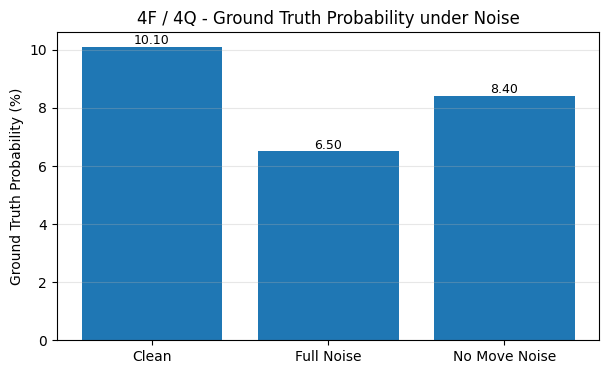

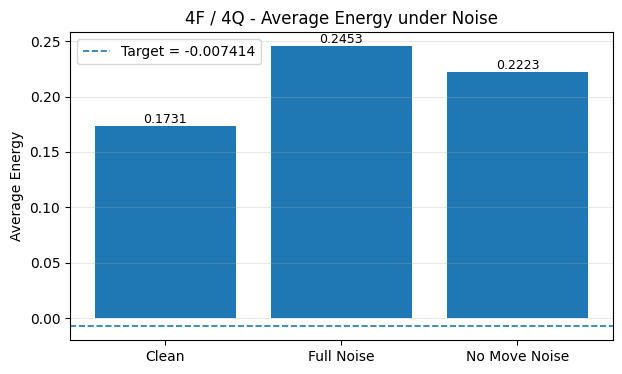

In [50]:
def plot_noise_summary(results, target_energy=None):
    labels = ["Clean", "Full Noise", "No Move Noise"]
    keys = ["clean", "one_zone_full", "one_zone_no_moves"]

    gt_probs = [100 * results[k]["gt_probability"] for k in keys]
    avg_energies = [results[k]["avg_energy"] for k in keys]

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, gt_probs)
    plt.ylabel("Ground Truth Probability (%)")
    plt.title("4F / 4Q - Ground Truth Probability under Noise")
    plt.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, gt_probs):
        plt.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )
    plt.show()

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, avg_energies)
    if target_energy is not None:
        plt.axhline(
            target_energy,
            linestyle="--",
            linewidth=1.2,
            label=f"Target = {target_energy:.6f}"
        )
        plt.legend()
    plt.ylabel("Average Energy")
    plt.title("4F / 4Q - Average Energy under Noise")
    plt.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, avg_energies):
        plt.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{v:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )
    plt.show()


plot_noise_summary(noise_results_4q, target_energy=GROUND_ENERGY)

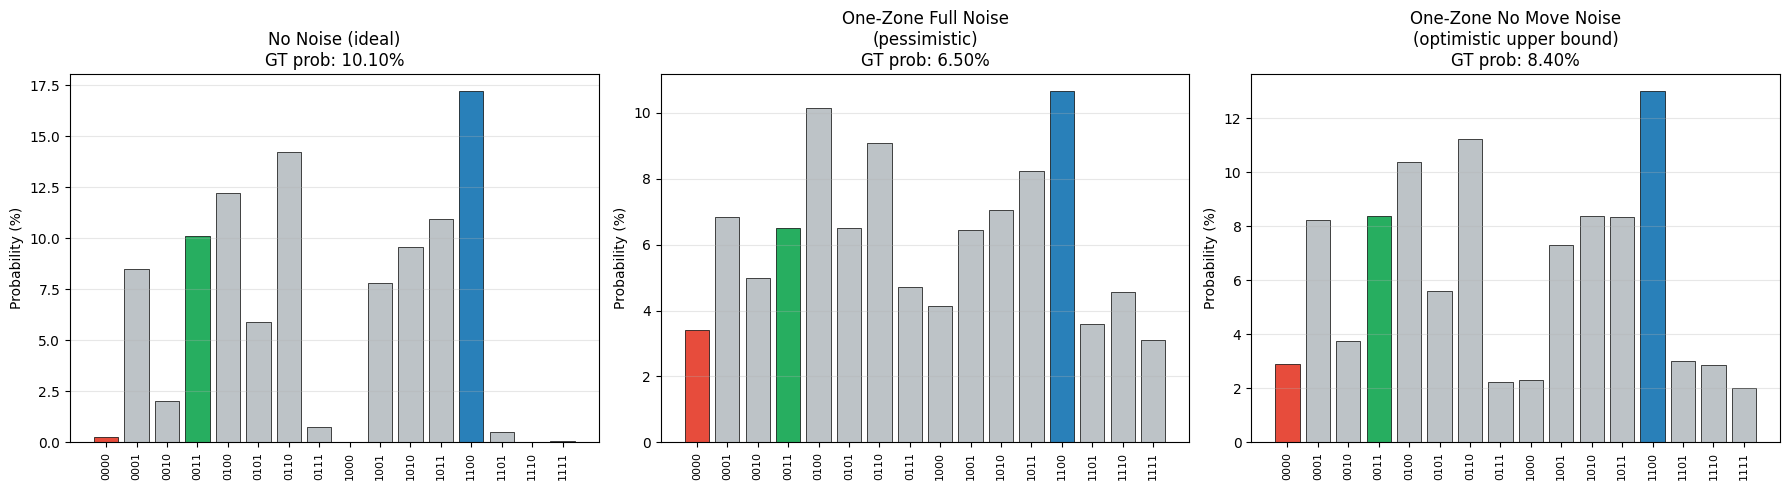

In [51]:
def plot_noise_distributions(results, shots=2000):
    all_states = [format(i, f"0{N_QUBITS}b") for i in range(2**N_QUBITS)]
    zero_state = "0" * N_QUBITS

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    titles = {
        "clean": "No Noise (ideal)",
        "one_zone_full": "One-Zone Full Noise\n(pessimistic)",
        "one_zone_no_moves": "One-Zone No Move Noise\n(optimistic upper bound)",
    }

    for ax, key in zip(axes, ["clean", "one_zone_full", "one_zone_no_moves"]):
        counts = results[key]["counts"]
        probs = [counts.get(s, 0) / shots * 100 for s in all_states]

        colors = []
        for s in all_states:
            if s == GROUND_TRUTH:
                colors.append("#27ae60")
            elif s == zero_state:
                colors.append("#e74c3c")
            elif evaluate_ising(s) < 0:
                colors.append("#2980b9")
            else:
                colors.append("#bdc3c7")

        ax.bar(
            range(len(all_states)),
            probs,
            color=colors,
            edgecolor="black",
            linewidth=0.5
        )
        ax.set_xticks(range(len(all_states)))
        ax.set_xticklabels(all_states, rotation=90, fontsize=8)
        ax.set_ylabel("Probability (%)")
        ax.set_title(f'{titles[key]}\nGT prob: {100 * results[key]["gt_probability"]:.2f}%')
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_noise_distributions(noise_results_4q, shots=2000)